# Volatilidad, tasas y crédito en Python
### Clase 3: Práctica (2 h) — Guía para el alumno
**Finanzas Cuantitativas, la Ciencia y los Mercados**
FCEN-UBA · Guido Schifani

---

En la teórica vimos los modelos que la industria usa cuando Black-Scholes no alcanza.
Ahora los hacemos funcionar:

| Ejercicio | Tema | Qué hacemos |
|---|---|---|
| **1** | Dupire | Vol local del SPX real, y por qué predice mal el skew hacia adelante |
| **2** | Heston vs GBM | Monte Carlo de ambos → el smile **emerge** del modelo, no se pone a mano |
| **3** | Vasicek / CIR | Calibrar la reversión a la media con la tasa corta real (`^IRX`) |
| **4** | Merton | Probabilidad de default de dos empresas reales, desde el balance y el mercado |
| **5** | SABR *(colchón)* | Ajustar la fórmula de Hagan al smile real del SPX y leer ρ y ν como un trader |

**Cómo trabajar este notebook:** cada ejercicio arranca con las preguntas que tienen que responder. Léanlas antes de correr nada, después ejecuten el código en orden y usen los números y gráficos que produce para contestarlas.

La regla de hoy: **un modelo se entiende cuando lo simulaste, lo calibraste y viste dónde falla.**

---
## Preguntas de la práctica

Lean todas las preguntas antes de correr nada: son la guía de qué mirar en cada ejercicio. Después corran el código de cada sección en orden y respondan acá abajo o donde el docente indique.

**Ejercicio 1, Dupire en vivo: vol local del SPX real, y el aplanamiento hacia adelante**

1. ¿El lado CALL de la figura es tan prolijo como el lado PUT?
2. ¿Cuántos strikes dieron σ_local negativo (los "recortados" que imprime el código)?

**Ejercicio 2, Heston vs GBM: el smile emerge**

1. Si ponen `rho=0`, ¿qué le pasa al skew?
2. ¿El smile de Heston se parece al del SPX real (clase 2)?

**Ejercicio 3: Vasicek y CIR — el resorte que vuelve (y el que no)**

1. ¿Qué porcentaje de los caminos de Vasicek terminó en negativo? ¿Y de CIR?
2. ¿Qué revierte más rápido: la simulación de la Parte A o el spread SOFR-EFFR real de la Parte B?
3. ¿Por cuántos puntos básicos difiere la curva simulada de Hull-White de la curva real de mercado?

**Ejercicio 4, Merton en vivo: la probabilidad de default desde el mercado**

1. ¿Cuál de las dos empresas tiene mayor probabilidad de default?
2. Si suben la deuda de Apple ×5, ¿qué le pasa a la PD?

**Ejercicio 5 *(colchón)*: SABR sobre el smile real del SPX**

1. ¿Qué tan chico dio el error (RMSE) del ajuste de SABR?
2. ¿El ρ de SABR se parece al de Heston (Ejercicio 2)?

**Extra (opcional): cuando el precio salta — Merton jump-diffusion**

1. En el gráfico de la sonrisa, ¿la curva de Merton tiene forma de sonrisa y la de GBM sale plana?
2. Si suben λ, ¿la sonrisa se hace más pronunciada?

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import requests
from scipy.optimize import minimize, brentq, fsolve
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

NAVY, VIOLET, ORANGE = '#1E1B4B', '#4B3FA0', '#E8602C'
GREEN, RED = '#2E7D32', '#C62828'
plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.grid': True, 'grid.alpha': 0.3})

# El pricer de Black-Scholes de la clase 2, hoy es nuestra REGLA DE MEDIR:
# lo usamos para traducir precios (de cualquier modelo) a vol implícita
def bs_call(S, K, T, r, sigma, q=0.0):
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def vol_implicita(precio, S, K, T, r, q=0.0):
    try:
        return brentq(lambda s: bs_call(S, K, T, r, s, q) - precio, 1e-4, 3.0)
    except ValueError:
        return np.nan

print('Pricer BS listo, chequeo:', round(bs_call(100, 100, 0.5, 0.03, 0.20), 4))

Pricer BS listo, chequeo: 6.371


---
# Ejercicio 1, Dupire en vivo: vol local del SPX real, y el aplanamiento hacia adelante

## La idea

En la teórica (§2) vimos la fórmula de Dupire, $\sigma_{local}^2(K,T) = \dfrac{2\,\partial C/\partial T}{K^2\,\partial^2 C/\partial K^2}$
,  y la falla famosa: vol local predice que la sonrisa queda "pegada" a los strikes (sticky
strike), así que si el spot se mueve, el ATM vol de mañana cambia MUCHO más de lo que el
mercado en la práctica muestra (sticky moneyness). En la teórica lo vimos con una curva
sintética. Ahora lo hacemos con la cadena real del SPX.

Necesitamos DOS vencimientos (para estimar $\partial C/\partial T$ por diferencias finitas) , 
todo lo demás (mid pricing, invertir BS, suavizar el smile) ya lo hicieron en la clase 2 y en el
Ejercicio de SABR de esta clase.

Si Yahoo falla, hay un par de smiles de respaldo (medidos al preparar la clase).


In [5]:
# ── Datos: dos vencimientos del SPX real (hace falta ∂C/∂T) ───────────────────
def smile_spx_expiry(spx, S0, expiry, T, r=0.037, q=0.013):
    """Mismo patrón que el Ejercicio de SABR: mid price, bid/ask>0, invertir BS."""
    ch = spx.option_chain(expiry)
    pts = []
    for df, tipo in [(ch.puts, 'put'), (ch.calls, 'call')]:
        df = df[(df.bid > 0) & (df.ask > 0)].copy()
        df['mid'] = (df.bid + df.ask) / 2
        for _, row in df.iterrows():
            K = row['strike']
            if not (0.85*S0 < K < 1.15*S0):
                continue
            if tipo == 'call' and K < S0:
                continue
            if tipo == 'put' and K > S0:
                continue
            objetivo = row['mid'] if tipo == 'call' else row['mid'] + S0*np.exp(-q*T) - K*np.exp(-r*T)
            iv = vol_implicita(objetivo, S0, K, T, r, q)
            if not np.isnan(iv):
                pts.append((K, iv))
    pts = sorted(pts)
    return np.array([p[0] for p in pts]), np.array([p[1] for p in pts])


def dos_smiles_spx():
    spx = yf.Ticker('^SPX')
    S0 = float(spx.history(period='1d')['Close'].iloc[-1])
    hoy = pd.Timestamp.today().normalize()
    dias = {e: (pd.Timestamp(e) - hoy).days for e in spx.options}
    e1 = next(e for e, d in sorted(dias.items(), key=lambda x: x[1]) if 25 <= d <= 45)
    e2 = next(e for e, d in sorted(dias.items(), key=lambda x: x[1]) if 85 <= d <= 140)
    T1, T2 = dias[e1]/365, dias[e2]/365
    K1, iv1 = smile_spx_expiry(spx, S0, e1, T1)
    K2, iv2 = smile_spx_expiry(spx, S0, e2, T2)
    return S0, (T1, K1, iv1), (T2, K2, iv2)


try:
    S0d, (T1d, K1d, iv1d), (T2d, K2d, iv2d) = dos_smiles_spx()
    fuente_d = 'en vivo (SPX)'
except Exception as e:
    S0d = 7785.8
    T1d, T2d = 0.068, 0.266
    mon1 = np.array([0.90, 0.93, 0.95, 0.97, 0.99, 1.00, 1.01, 1.03, 1.05, 1.08])
    iv1d = np.array([0.225, 0.185, 0.160, 0.138, 0.120, 0.113, 0.108, 0.100, 0.100, 0.108])
    mon2 = np.array([0.88, 0.91, 0.94, 0.97, 1.00, 1.03, 1.06, 1.09, 1.12])
    iv2d = np.array([0.196, 0.170, 0.148, 0.130, 0.118, 0.111, 0.108, 0.109, 0.114])
    K1d, K2d = mon1*S0d, mon2*S0d
    fuente_d = f'⚠ smiles de respaldo ago-2026 ({e})'

print(f'[{fuente_d}]  S₀ = {S0d:.0f}   T₁ = {T1d:.3f} ({len(K1d)} pts)   T₂ = {T2d:.3f} ({len(K2d)} pts)')


[en vivo (SPX)]  S₀ = 7592   T₁ = 0.068 (0 pts)   T₂ = 0.271 (0 pts)


In [6]:
# ── Suavizar cada smile, repreciar en una grilla común, y armar Dupire ─────────
r_d, q_d = 0.037, 0.013

coef1 = np.polyfit(K1d/S0d, iv1d, deg=4)
coef2 = np.polyfit(K2d/S0d, iv2d, deg=4)

K_fina = np.linspace(0.85*S0d, 1.15*S0d, 300)
iv1_fina = np.polyval(coef1, K_fina/S0d)
iv2_fina = np.polyval(coef2, K_fina/S0d)

C1_fina = bs_call(S0d, K_fina, T1d, r_d, iv1_fina, q_d)
C2_fina = bs_call(S0d, K_fina, T2d, r_d, iv2_fina, q_d)

dCdT   = (C2_fina - C1_fina) / (T2d - T1d)
d2CdK2 = np.gradient(np.gradient(C1_fina, K_fina), K_fina)

sigma_loc2 = 2*dCdT / (K_fina**2 * d2CdK2)
sigma_loc  = np.sqrt(np.clip(sigma_loc2, 1e-6, None))   # red de seguridad, no debería recortar nada

n_recortados = int(np.sum(sigma_loc2 <= 0))
print(f'σ_local calculada en {len(K_fina)} strikes, {n_recortados} valores negativos recortados (arbitraje numérico de la superficie ruidosa)')


TypeError: expected non-empty vector for x

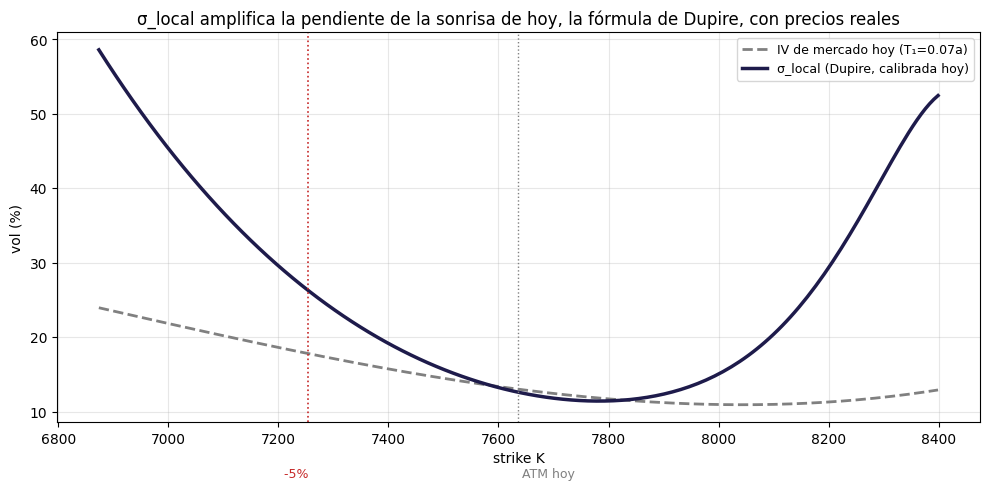

In [ ]:
# ── La figura: σ_local(K) vs. la sonrisa implícita de hoy ──────────────────────
ver = (K_fina > 0.90*S0d) & (K_fina < 1.10*S0d)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_fina[ver], 100*iv1_fina[ver], color='gray', lw=2, ls='--', label=f'IV de mercado hoy (T₁={T1d:.2f}a)')
ax.plot(K_fina[ver], 100*sigma_loc[ver], color=NAVY, lw=2.5, label='σ_local (Dupire, calibrada hoy)')
ax.axvline(S0d, color='gray', lw=1, ls=':')
ax.axvline(0.95*S0d, color=RED, lw=1.2, ls=':')
ax.text(S0d, ax.get_ylim()[1]*0.02, ' ATM hoy', fontsize=9, color='gray')
ax.text(0.95*S0d, ax.get_ylim()[1]*0.02, ' -5%', fontsize=9, color=RED, ha='right')
ax.set_xlabel('strike K'); ax.set_ylabel('vol (%)')
ax.set_title('σ_local amplifica la pendiente de la sonrisa de hoy, la fórmula de Dupire, con precios reales')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


In [ ]:
# ── El test: ¿qué predice vol local si el spot cae 5%? ─────────────────────────
K_atm  = S0d
K_down = 0.95*S0d

sigma_atm  = np.interp(K_atm,  K_fina, sigma_loc)
sigma_down = np.interp(K_down, K_fina, sigma_loc)
iv_atm_hoy = np.interp(K_atm,  K_fina, iv1_fina)

print(f'σ_local en el ATM de hoy (K={K_atm:.0f}):           {sigma_atm:.1%}')
print(f'σ_local en K={K_down:.0f} (-5%, el ATM de "mañana si cae"): {sigma_down:.1%}')
print(f'vs. la IV de mercado ATM de hoy:                     {iv_atm_hoy:.1%}')
print()
print(f'Sticky strike (lo que predice Dupire): si el spot cae 5% mañana, el ATM salta a ~{sigma_down:.0%}')
print(f'Sticky moneyness (lo que el mercado tiende a hacer): el ATM se queda cerca de {iv_atm_hoy:.0%}')


σ_local en el ATM de hoy (K=7636):           12.6%
σ_local en K=7255 (-5%, el ATM de "mañana si cae"): 26.3%
vs. la IV de mercado ATM de hoy:                     13.0%

Sticky strike (lo que predice Dupire): si el spot cae 5% mañana, el ATM salta a ~26%
Sticky moneyness (lo que el mercado tiende a hacer): el ATM se queda cerca de 13%


---
# Ejercicio 2, Heston vs GBM: el smile emerge

## La idea

En la teórica (§3) dijimos que en Heston el smile no se pone a mano: **emerge** de la dinámica
(ρ < 0 → skew, ξ > 0 → curvatura). Vamos a demostrarlo por fuerza bruta:

1. Simulamos dos mundos con la **misma varianza de largo plazo**: un GBM con $\sigma = \sqrt{\theta}$
   y un Heston con $v_0 = \theta$, $\rho = -0.7$, $\xi = 0.6$.
2. En cada mundo priceamos calls por Monte Carlo en una grilla de strikes.
3. Invertimos cada precio con el pricer de BS → la vol implícita strike por strike.

**Detalle numérico:** discretizamos la varianza con Euler *full truncation* ($\sqrt{\max(v,0)}$) , 
el esquema estándar cuando la condición de Feller no se cumple ($2\kappa\theta = 0.16 < \xi^2 = 0.36$),
que es lo habitual en parámetros calibrados a mercado.

In [ ]:
def simular_heston(S0=100., v0=0.04, r=0.03, kappa=2.0, theta=0.04, xi=0.6, rho=-0.7,
                   T=0.5, n_steps=126, n_paths=100_000, seed=42):
    """Devuelve S_T bajo Heston (Euler full truncation, log-precio exacto en v)."""
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    lnS = np.full(n_paths, np.log(S0))
    v   = np.full(n_paths, v0)
    for _ in range(n_steps):
        z1 = rng.standard_normal(n_paths)
        z2 = rho*z1 + np.sqrt(1 - rho**2)*rng.standard_normal(n_paths)
        v_pos = np.maximum(v, 0.0)                      # full truncation
        lnS  += (r - 0.5*v_pos)*dt + np.sqrt(v_pos*dt)*z1
        v    += kappa*(theta - v_pos)*dt + xi*np.sqrt(v_pos*dt)*z2
    return np.exp(lnS)

def simular_gbm(S0=100., sigma=0.20, r=0.03, T=0.5, n_paths=100_000, seed=42):
    rng = np.random.default_rng(seed)
    z = rng.standard_normal(n_paths)
    return S0*np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*z)

S0, r, T, theta = 100., 0.03, 0.5, 0.04
ST_heston = simular_heston(S0=S0, r=r, T=T, v0=theta, theta=theta)
ST_gbm    = simular_gbm(S0=S0, sigma=np.sqrt(theta), r=r, T=T)
print(f'Simulados {len(ST_heston):,} caminos por modelo')
print(f'E[S_T] Heston: {ST_heston.mean():.2f} | GBM: {ST_gbm.mean():.2f} | teórico: {S0*np.exp(r*T):.2f}')
print(f'Kurtosis de ln(S_T), Heston: {pd.Series(np.log(ST_heston)).kurtosis():.2f} | GBM: {pd.Series(np.log(ST_gbm)).kurtosis():.2f}')

Simulados 100,000 caminos por modelo
E[S_T] Heston: 101.56 | GBM: 101.46 | teórico: 101.51
Kurtosis de ln(S_T), Heston: 5.21 | GBM: 0.02


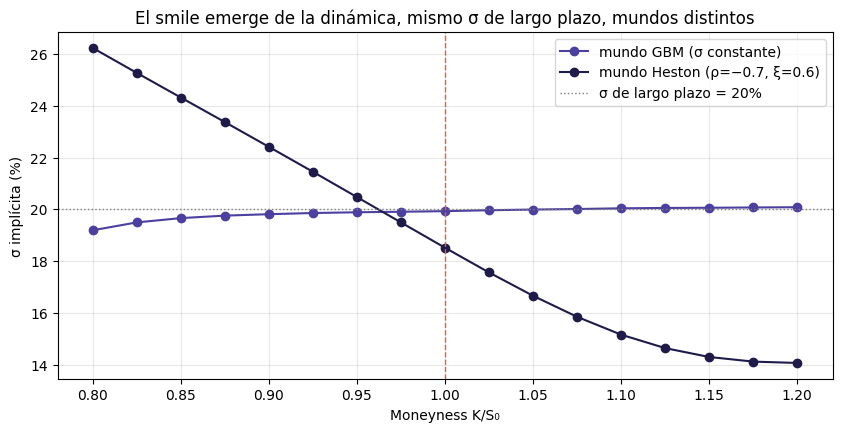

IV en K/S₀=0.80, Heston: 26.2%  vs  GBM: 19.2%
IV ATM, Heston: 18.5%  vs  GBM: 19.9%
IV en K/S₀=1.20, Heston: 14.1%  vs  GBM: 20.1%


In [ ]:
# ── Pricear por MC en una grilla de strikes e invertir con BS ─────────────────
strikes = np.arange(80, 122, 2.5)
disc = np.exp(-r*T)

iv_h, iv_g = [], []
for K in strikes:
    c_h = disc * np.maximum(ST_heston - K, 0).mean()
    c_g = disc * np.maximum(ST_gbm    - K, 0).mean()
    iv_h.append(vol_implicita(c_h, S0, K, T, r))
    iv_g.append(vol_implicita(c_g, S0, K, T, r))

plt.plot(strikes/S0, np.array(iv_g)*100, 'o-', color=VIOLET, label='mundo GBM (σ constante)')
plt.plot(strikes/S0, np.array(iv_h)*100, 'o-', color=NAVY, label='mundo Heston (ρ=−0.7, ξ=0.6)')
plt.axhline(np.sqrt(theta)*100, color='gray', ls=':', lw=1, label='σ de largo plazo = 20%')
plt.axvline(1.0, color=ORANGE, ls='--', lw=1)
plt.xlabel('Moneyness K/S₀'); plt.ylabel('σ implícita (%)')
plt.title('El smile emerge de la dinámica, mismo σ de largo plazo, mundos distintos')
plt.legend(); plt.show()

print(f'IV en K/S₀=0.80, Heston: {iv_h[0]*100:.1f}%  vs  GBM: {iv_g[0]*100:.1f}%')
print(f'IV ATM, Heston: {iv_h[8]*100:.1f}%  vs  GBM: {iv_g[8]*100:.1f}%')
print(f'IV en K/S₀=1.20, Heston: {iv_h[-1]*100:.1f}%  vs  GBM: {iv_g[-1]*100:.1f}%')

---
# Ejercicio 3: Vasicek y CIR — el resorte que vuelve (y el que no)

## Parte A, la idea, simulada primero

Vasicek dice $dr = \kappa(\theta - r)\,dt + \sigma\,dW$: un resorte (el mismo OU de la clase 2)
tirando la tasa hacia $\theta$. Antes de ensuciarnos con datos reales, la simulamos: arrancar
desde varios puntos y ver cómo todos convergen a $\theta$.

CIR agrega una sola letra: $dr = \kappa(\theta-r)\,dt + \sigma\sqrt{r}\,dW$. Esa $\sqrt{r}$ apaga
el ruido cuando $r\to 0$, así que la tasa nunca cruza cero — a diferencia de Vasicek, que si el
shock es lo bastante negativo, sí puede.

## Parte B, ver la reversión rápida de verdad: el spread SOFR − EFFR

El nivel GENERAL de las tasas (probamos con `^IRX` en una versión anterior de este ejercicio)
revierte muy despacio en la vida real — la política monetaria se mueve en años, no en días.
Pero no todas las tasas se mueven así: el **spread entre SOFR** (la tasa de repo overnight,
garantizada con Treasuries) **y la EFFR** (la tasa efectiva de fondos federales) mide fricciones
puntuales del mercado de financiamiento de corto plazo, y esas SÍ se resuelven rápido.

Ese spread salta típicamente en los cierres de trimestre (los bancos achican su balance por
regulación) y vuelve a cero en cuestión de días. El ejemplo más famoso: la **crisis de repo de
septiembre de 2019**, cuando SOFR saltó a 5.25% de un día para el otro por un faltante puntual
de reservas — y volvió a la normalidad en menos de una semana.

Calibramos el mismo AR(1) de Vasicek, ahora sobre este spread en vez de sobre el nivel de la tasa.


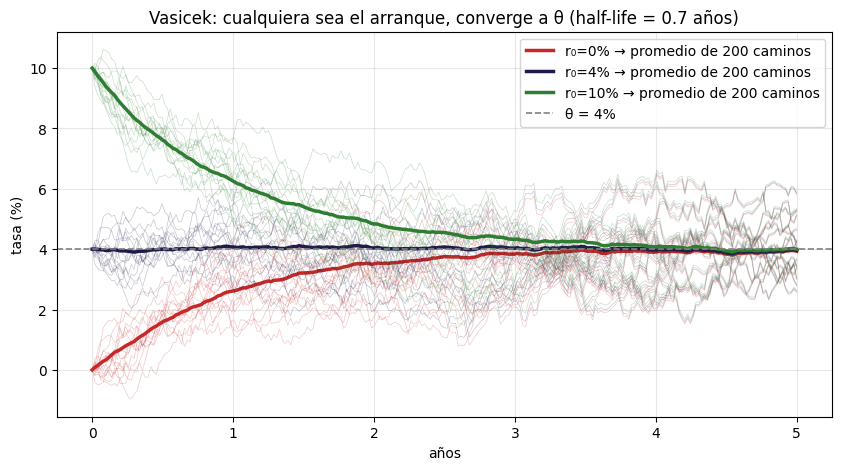

In [ ]:
# ── Parte A.1 — Simular Vasicek: no importa dónde arranque, converge a θ ─────
def simular_vasicek(r0, kappa, theta, sigma, T=5, pasos=252, n_paths=200, seed=0):
    rng = np.random.default_rng(seed)
    dt = T / pasos
    r = np.full((n_paths, pasos + 1), r0)
    for t in range(pasos):
        r[:, t+1] = r[:, t] + kappa*(theta - r[:, t])*dt + sigma*np.sqrt(dt)*rng.standard_normal(n_paths)
    return r

kappa_j, theta_j, sigma_j = 1.0, 0.04, 0.015     # parámetros de juguete, half-life corto para VERLO
tiempo = np.linspace(0, 5, 253)

fig, ax = plt.subplots(figsize=(10, 5))
for r0, color in [(0.00, RED), (0.04, NAVY), (0.10, GREEN)]:
    caminos = simular_vasicek(r0, kappa_j, theta_j, sigma_j)
    ax.plot(tiempo, caminos[:15].T * 100, color=color, lw=0.5, alpha=0.25)
    ax.plot(tiempo, caminos.mean(axis=0) * 100, color=color, lw=2.5,
            label=f'r₀={r0:.0%} → promedio de 200 caminos')
ax.axhline(theta_j * 100, color='gray', ls='--', lw=1.2, label=f'θ = {theta_j:.0%}')
ax.set_xlabel('años'); ax.set_ylabel('tasa (%)')
ax.set_title(f'Vasicek: cualquiera sea el arranque, converge a θ (half-life = {np.log(2)/kappa_j:.1f} años)')
ax.legend(); plt.show()

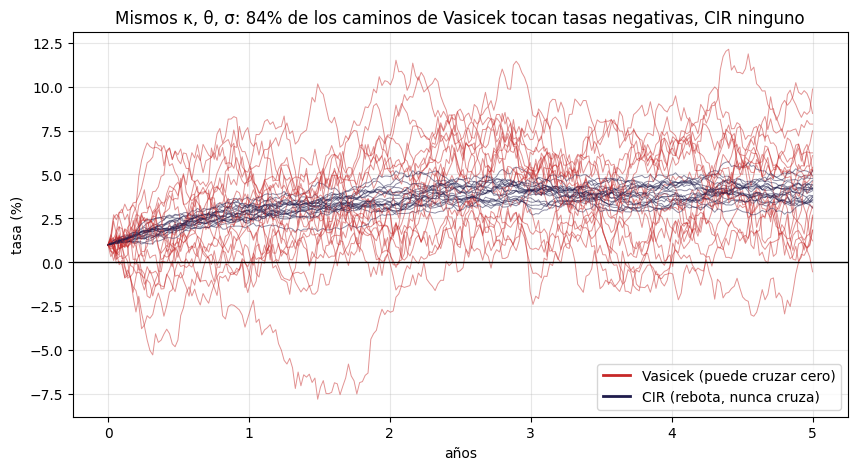

In [ ]:
# ── Parte A.2 — Vasicek vs CIR: mismos κ, θ, σ, un salvavidas distinto en cero ──
def simular_cir(r0, kappa, theta, sigma, T=5, pasos=252, n_paths=200, seed=0):
    rng = np.random.default_rng(seed)
    dt = T / pasos
    r = np.full((n_paths, pasos + 1), r0)
    for t in range(pasos):
        r_pos = np.maximum(r[:, t], 0)
        r[:, t+1] = r[:, t] + kappa*(theta - r[:, t])*dt + sigma*np.sqrt(r_pos*dt)*rng.standard_normal(n_paths)
    return r

r0_bajo, sigma_alto = 0.01, 0.04    # arrancar cerca de 0 con ruido grande: donde se nota la diferencia
vas = simular_vasicek(r0_bajo, kappa_j, theta_j, sigma_alto, seed=1)
cir = simular_cir(r0_bajo, kappa_j, theta_j, sigma_alto, seed=1)
pct_negativos = (vas < 0).any(axis=1).mean()

fig, ax = plt.subplots(figsize=(10, 5))
for i in range(20):
    ax.plot(tiempo, vas[i] * 100, color=RED, lw=0.7, alpha=0.5)
    ax.plot(tiempo, cir[i] * 100, color=NAVY, lw=0.7, alpha=0.5)
ax.plot([], [], color=RED, lw=2, label='Vasicek (puede cruzar cero)')
ax.plot([], [], color=NAVY, lw=2, label='CIR (rebota, nunca cruza)')
ax.axhline(0, color='k', lw=1)
ax.set_xlabel('años'); ax.set_ylabel('tasa (%)')
ax.set_title(f'Mismos κ, θ, σ: {pct_negativos:.0%} de los caminos de Vasicek tocan tasas negativas, CIR ninguno')
ax.legend(); plt.show()

[datos en vivo (FRED)] 2106 observaciones, 2018-04-03 → 2026-09-08


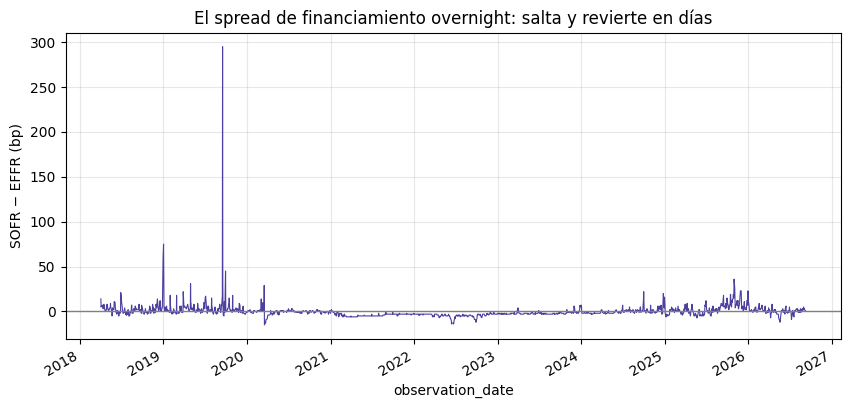

In [ ]:
# ── Datos: spread SOFR − EFFR (FRED), la parte de las tasas que revierte RÁPIDO ──
def fred(sid):
    r = requests.get(f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}', timeout=20)
    df = pd.read_csv(pd.io.common.StringIO(r.text), parse_dates=['observation_date'])
    s = df.set_index('observation_date')[sid]
    return pd.to_numeric(s, errors='coerce').dropna()

try:
    sofr, effr = fred('SOFR'), fred('EFFR')
    idx_comun = sofr.index.intersection(effr.index)
    spread = (sofr.loc[idx_comun] - effr.loc[idx_comun]) / 100    # a decimal, como el resto del notebook
    fuente = 'datos en vivo (FRED)'
except Exception as e:
    fuente = f'⚠ respaldo sintético ({e})'
    rng = np.random.default_rng(3)
    idx_comun = pd.date_range('2018-04-03', periods=2100, freq='B')
    n = len(idx_comun)
    vals = np.zeros(n)
    for i in range(1, n):
        salto = rng.uniform(0.0005, 0.0030) if i % 63 in (0, 1) else 0.0   # ~fin de trimestre
        vals[i] = vals[i-1] + 5.0*(0.0 - vals[i-1])/252 + 0.00003*rng.standard_normal() + salto
    spread = pd.Series(vals, index=idx_comun)

print(f'[{fuente}] {len(spread)} observaciones, {spread.index[0].date()} → {spread.index[-1].date()}')

(spread * 1e4).plot(color=VIOLET, lw=0.8)
plt.axhline(0, color='gray', lw=1)
plt.ylabel('SOFR − EFFR (bp)'); plt.title('El spread de financiamiento overnight: salta y revierte en días')
plt.show()

In [ ]:
# ── Calibración Vasicek por AR(1), sobre el spread (no sobre el nivel) ────────
dt_ = 1/252
x_t, x_t1 = spread.values[:-1], spread.values[1:]

b, a = np.polyfit(x_t, x_t1, 1)
resid = x_t1 - (a + b*x_t)

kappa  = -np.log(b) / dt_
theta_ = a / (1 - b)
sigma_ = resid.std() / np.sqrt(dt_)
half_life_dias = (np.log(2) / kappa) * 365

print(f'Vasicek calibrado sobre el spread SOFR-EFFR (AR(1) diario):')
print(f'   κ = {kappa:.2f}  →  half-life = {half_life_dias:.1f} DÍAS (no años)')
print(f'   θ = {theta_*1e4:+.1f} bp   (el spread "de reposo", debería rondar 0)')
print(f'   σ = {sigma_*1e4:.0f} bp de vol anual')
print()
print(f'El pico más grande: {spread.max()*1e4:.0f}bp, el {spread.idxmax().date()} '
      f'(la crisis de repo de septiembre 2019)')

Vasicek calibrado sobre el spread SOFR-EFFR (AR(1) diario):
   κ = 241.68  →  half-life = 1.0 DÍAS (no años)
   θ = -0.2 bp   (el spread "de reposo", debería rondar 0)
   σ = 121 bp de vol anual

El pico más grande: 295bp, el 2019-09-17 (la crisis de repo de septiembre 2019)


## Parte C, la cura: Hull-White calibra la curva de hoy

Vasicek y CIR (Partes A y B) comparten un defecto que la teórica (§5) ya advirtió: son
**endógenos** — su curva de bonos P(0,T) no tiene por qué coincidir con la curva de mercado de
hoy, porque θ es una constante que el modelo elige, no algo que "recuerde" la curva observada.

Hull-White (1990) hace con θ el mismo movimiento que Dupire hizo con la volatilidad (§2):
promoverlo de constante a función del tiempo, calibrada para que el modelo respete la curva
observada EXACTAMENTE:

$$dr = [\theta(t) - a\,r]\,dt + \sigma\,dW, \qquad \theta(t) = \frac{\partial f(0,t)}{\partial t} + a\,f(0,t) + \frac{\sigma^2}{2a}\bigl(1-e^{-2at}\bigr)$$

donde $f(0,t)$ es la curva forward instantánea de HOY. El plan: bajar la curva real del Tesoro
(los mismos 4 tickers de la clase 1: `^IRX`, `^FVX`, `^TNX`, `^TYX`), ajustar Nelson-Siegel (4
puntos, 4 parámetros — NSS sobreparametrizaría), derivar $f(0,T)$, calibrar $\theta(t)$, simular
miles de caminos, y VERIFICAR que el precio de bonos que sale de la simulación reproduce la curva
de mercado de la que partimos.

**Nota:** $a$ y $\sigma$ (la velocidad y la vol del corto plazo) se calibran en la práctica contra
precios de swaptions — acá los fijamos en valores ilustrativos razonables.


In [ ]:
# ── Parte C.1 — Bajar la curva del Tesoro (4 puntos, como en la clase 1) y ajustar Nelson-Siegel ──
tickers_curva = {'^IRX': 0.25, '^FVX': 5, '^TNX': 10, '^TYX': 30}
try:
    y_obs = np.array([yf.Ticker(tk).history(period='5d')['Close'].dropna().iloc[-1] / 100
                       for tk in tickers_curva])
    fuente_curva = 'datos en vivo (Yahoo Finance)'
except Exception as e:
    fuente_curva = f'⚠ respaldo sintético ({e})'
    y_obs = np.array([0.0375, 0.0455, 0.0480, 0.0525])   # curva de referencia, fechada 8-sep-2026
T_obs = np.array(list(tickers_curva.values()))

def ns_yield(T, beta0, beta1, beta2, tau):
    T = np.asarray(T, dtype=float)
    x = T / tau
    factor = (1 - np.exp(-x)) / x
    return beta0 + beta1*factor + beta2*(factor - np.exp(-x))

def error_ns(p):
    if p[3] <= 0.05:
        return 1e6
    return np.sum((ns_yield(T_obs, *p) - y_obs)**2)

res = minimize(error_ns, x0=[0.04, -0.01, 0.01, 5.0], method='Nelder-Mead',
               options={'xatol': 1e-10, 'fatol': 1e-14, 'maxiter': 20000, 'maxfev': 20000})
beta0, beta1, beta2, tau = res.x
rmse_bp = np.sqrt(res.fun / len(T_obs)) * 1e4

print(f'[{fuente_curva}]')
for tk, T, y in zip(tickers_curva, T_obs, y_obs):
    print(f'   {tk:<6} (T={T:>5.2f}a): {y:.2%}')
print(f'Nelson-Siegel: β0={beta0:.4f}  β1={beta1:.4f}  β2={beta2:.4f}  τ={tau:.2f}   (RMSE {rmse_bp:.1f}bp)')

[datos en vivo (Yahoo Finance)]
   ^IRX   (T= 0.25a): 3.80%
   ^FVX   (T= 5.00a): 4.61%
   ^TNX   (T=10.00a): 4.84%
   ^TYX   (T=30.00a): 5.29%
Nelson-Siegel: β0=0.0546  β1=-0.0170  β2=-0.0000  τ=3.44   (RMSE 4.5bp)


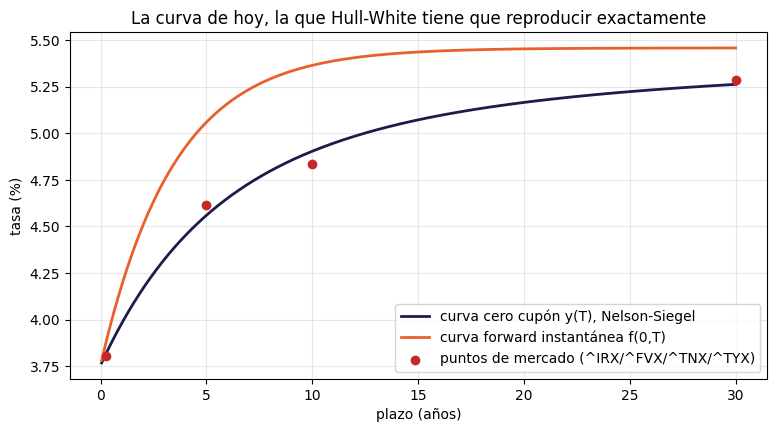

In [ ]:
# ── Parte C.2 — La curva forward instantánea f(0,T), lo que Hull-White debe respetar ──
T_fina = np.linspace(0.05, 30, 3000)
y_fina = ns_yield(T_fina, beta0, beta1, beta2, tau)
fwd = np.gradient(y_fina * T_fina, T_fina)          # f(0,T) = d(y·T)/dT

plt.figure(figsize=(9, 4.5))
plt.plot(T_fina, y_fina*100, color=NAVY, lw=2, label='curva cero cupón y(T), Nelson-Siegel')
plt.plot(T_fina, fwd*100, color=ORANGE, lw=2, label='curva forward instantánea f(0,T)')
plt.scatter(T_obs, y_obs*100, color=RED, zorder=5, label='puntos de mercado (^IRX/^FVX/^TNX/^TYX)')
plt.xlabel('plazo (años)'); plt.ylabel('tasa (%)')
plt.title('La curva de hoy, la que Hull-White tiene que reproducir exactamente')
plt.legend(); plt.show()

In [ ]:
# ── Parte C.3 — Calibrar θ(t) y simular Hull-White ────────────────────────────
a_hw, sigma_hw = 0.10, 0.010     # velocidad y vol del corto plazo (en la práctica: swaptions)

dfdT = np.gradient(fwd, T_fina)
theta_t = dfdT + a_hw*fwd + (sigma_hw**2/(2*a_hw))*(1 - np.exp(-2*a_hw*T_fina))
r0 = beta0 + beta1                 # el corto plazo de hoy: y(T→0)

pasos_por_año, T_max = 100, 30
n_steps = int(T_max * pasos_por_año)
dt = T_max / n_steps
t_grid = np.linspace(0, T_max, n_steps + 1)
theta_grid = np.interp(t_grid, T_fina, theta_t)

n_paths = 8000
rng = np.random.default_rng(11)
r_sim = np.full((n_paths, n_steps + 1), r0)
for i in range(n_steps):
    r_sim[:, i+1] = r_sim[:, i] + (theta_grid[i] - a_hw*r_sim[:, i])*dt + sigma_hw*np.sqrt(dt)*rng.standard_normal(n_paths)

print(f'a = {a_hw}, σ = {sigma_hw*1e4:.0f}bp (valores ilustrativos; en la práctica se calibran a swaptions)')
print(f'r0 (corto plazo de hoy) = {r0:.2%}   |   θ(t) va de {theta_t.min()*1e4:.0f}bp a {theta_t.max()*1e4:.0f}bp')

a = 0.1, σ = 100bp (valores ilustrativos; en la práctica se calibran a swaptions)
r0 (corto plazo de hoy) = 3.75%   |   θ(t) va de 60bp a 86bp


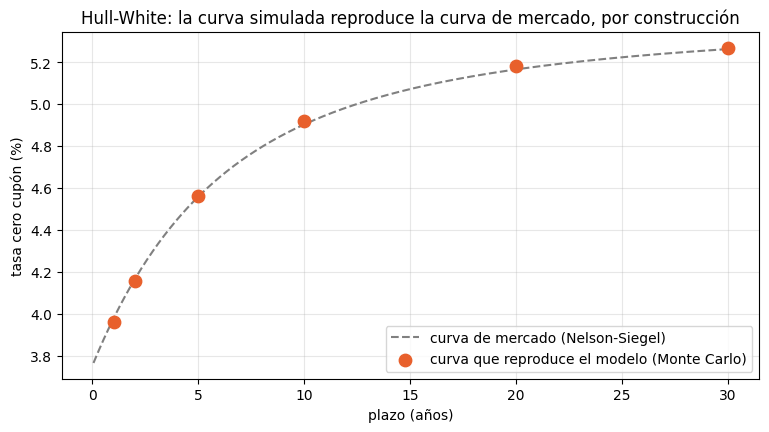

  T (años)   mercado    modelo  dif (bp)
         1     3.98%     3.96%     -1.7
         2     4.17%     4.16%     -1.1
         5     4.56%     4.56%      0.2
        10     4.90%     4.92%      1.5
        20     5.17%     5.18%      1.6
        30     5.26%     5.27%      0.5


In [ ]:
# ── Parte C.4 — Verificar: ¿el modelo reproduce la curva de la que partimos? ──
T_check = np.array([1, 2, 5, 10, 20, 30])
y_modelo, y_mercado = [], []
for Tc in T_check:
    idx = int(Tc * pasos_por_año)
    integral = np.trapz(r_sim[:, :idx+1], dx=dt, axis=1)
    P_modelo = np.mean(np.exp(-integral))
    y_modelo.append(-np.log(P_modelo) / Tc)
    y_mercado.append(np.interp(Tc, T_fina, y_fina))
y_modelo, y_mercado = np.array(y_modelo), np.array(y_mercado)

plt.figure(figsize=(9, 4.5))
plt.plot(T_fina, y_fina*100, color='gray', lw=1.5, ls='--', label='curva de mercado (Nelson-Siegel)')
plt.scatter(T_check, y_modelo*100, color=ORANGE, s=80, zorder=5, label='curva que reproduce el modelo (Monte Carlo)')
plt.xlabel('plazo (años)'); plt.ylabel('tasa cero cupón (%)')
plt.title('Hull-White: la curva simulada reproduce la curva de mercado, por construcción')
plt.legend(); plt.show()

print(f'{"T (años)":>10}{"mercado":>10}{"modelo":>10}{"dif (bp)":>10}')
for Tc, ym, ymod in zip(T_check, y_mercado, y_modelo):
    print(f'{Tc:>10.0f}{ym*100:>9.2f}%{ymod*100:>9.2f}%{(ymod-ym)*1e4:>9.1f}')

---
# Ejercicio 4, Merton en vivo: la probabilidad de default desde el mercado

## La idea

El modelo de Merton (§6): el equity es un **call sobre los activos** con strike la deuda. Observamos
$E$ (market cap) y $\sigma_E$ (vol del equity); despejamos lo que no se ve, $V$ y $\sigma_V$ , 
del sistema:

$$E = V\,N(d_1) - D\,e^{-rT}N(d_2) \qquad\qquad \sigma_E\,E = N(d_1)\,\sigma_V\,V$$

Dos ecuaciones, dos incógnitas → `fsolve`. Salida: **distancia al default** $DD = d_2$ (en sigmas)
y **probabilidad de default** $PD = N(-d_2)$.

Lo corremos para dos empresas contrastantes, una fortaleza de caja y una aerolínea apalancada , 
con equity y volatilidad **de mercado, de hoy**, y la deuda del último balance (hardcodeada y fechada:
los balances no viven en yfinance de forma confiable).

In [ ]:
# ── Datos: dos empresas contrastantes ─────────────────────────────────────────
# Deuda total (corto + largo plazo) de los últimos 10-K/10-Q, actualizar antes de la clase
EMPRESAS = {
    'AAPL': {'nombre': 'Apple (fortaleza)',          'deuda': 97e9},    # 10-K sep-2025, aprox
    'AAL':  {'nombre': 'American Airlines (apalancada)', 'deuda': 38e9},    # 10-K dic-2025, aprox
}

r_libre = 0.037   # tasa corta (^IRX), actualizar o bajar en vivo
T_m = 1.0         # horizonte estándar: 1 año

datos = {}
for tk, info in EMPRESAS.items():
    try:
        t = yf.Ticker(tk)
        E = float(t.fast_info['marketCap'])
        px = t.history(period='1y')['Close']
        sigma_E = float(np.log(px/px.shift(1)).dropna().std() * np.sqrt(252))
        fuente = 'vivo'
    except Exception:
        E, sigma_E = {'AAPL': (3.4e12, 0.25), 'AAL': (9e9, 0.45)}[tk]
        fuente = 'respaldo jul-2026'
    datos[tk] = {'E': E, 'sigma_E': sigma_E, 'D': info['deuda'], 'nombre': info['nombre'], 'fuente': fuente}
    print(f"{tk:<5} [{fuente}]  E = {E/1e9:,.0f} B$ | σ_E = {sigma_E:.0%} | D = {info['deuda']/1e9:.0f} B$ "
          f"| apalancamiento D/(D+E) = {info['deuda']/(info['deuda']+E):.0%}")

AAPL  [vivo]  E = 4,602 B$ | σ_E = 25% | D = 97 B$ | apalancamiento D/(D+E) = 2%
AAL   [vivo]  E = 9 B$ | σ_E = 47% | D = 38 B$ | apalancamiento D/(D+E) = 82%


In [ ]:
# ── Resolver el sistema de Merton para cada empresa ──────────────────────────
def merton(E, sigma_E, D, r, T):
    """Despeja (V, sigma_V) del sistema de Merton. Devuelve dict con DD y PD."""
    def sistema(x):
        V, sV = x
        d1 = (np.log(V/D) + (r + 0.5*sV**2)*T) / (sV*np.sqrt(T))
        d2 = d1 - sV*np.sqrt(T)
        ec1 = V*norm.cdf(d1) - D*np.exp(-r*T)*norm.cdf(d2) - E     # pricing del equity
        ec2 = norm.cdf(d1)*sV*V - sigma_E*E                        # vol apalancada (Itô)
        return [ec1, ec2]

    V0 = E + D                                  # punto inicial: balance contable
    sV0 = sigma_E * E / V0                      # vol desapalancada ingenua
    V, sV = fsolve(sistema, x0=[V0, sV0])
    d2 = (np.log(V/D) + (r - 0.5*sV**2)*T) / (sV*np.sqrt(T))
    return {'V': V, 'sigma_V': sV, 'DD': d2, 'PD': norm.cdf(-d2)}

print(f'{"":<6}{"V (B$)":>10}{"σ_V":>8}{"DD (σ)":>9}{"PD 1 año":>12}')
for tk, d in datos.items():
    m = merton(d['E'], d['sigma_E'], d['D'], r_libre, T_m)
    print(f"{tk:<6}{m['V']/1e9:>10,.0f}{m['sigma_V']:>8.0%}{m['DD']:>9.2f}{m['PD']:>12.2%}")


          V (B$)     σ_V   DD (σ)    PD 1 año
AAPL       4,696     24%    15.90       0.00%
AAL           45      9%     2.27       1.16%


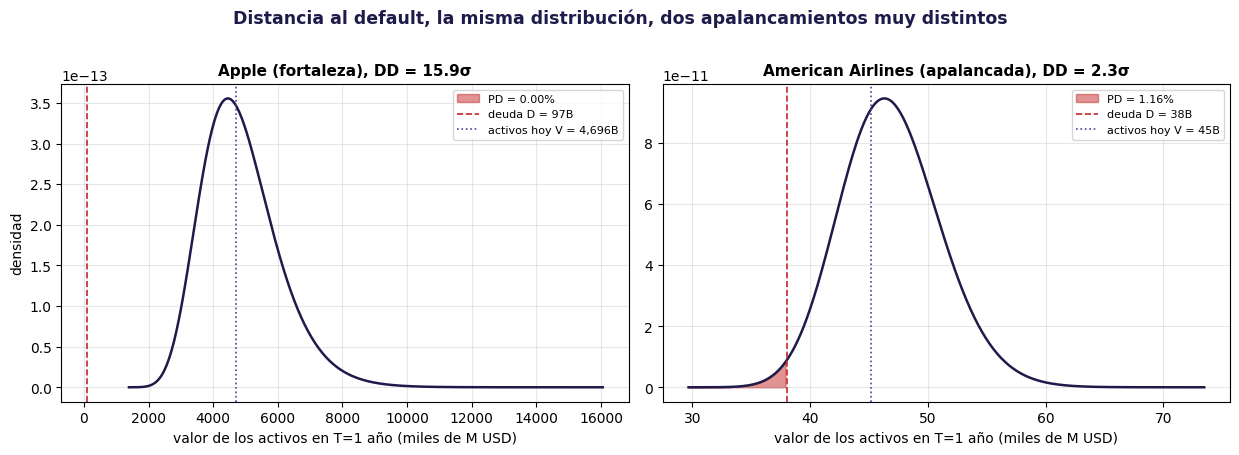

In [ ]:
# ── La figura: distancia al default, la distribución de V_T contra la barrera D ──
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
for ax, tk in zip(axes, datos):
    d = datos[tk]
    m = merton(d['E'], d['sigma_E'], d['D'], r_libre, T_m)
    V, sV, D = m['V'], m['sigma_V'], d['D']

    mu_log = np.log(V) + (r_libre - 0.5*sV**2)*T_m       # parámetros lognormales de V_T bajo Q
    sig_log = sV*np.sqrt(T_m)
    grilla = np.linspace(np.exp(mu_log - 5*sig_log), np.exp(mu_log + 5*sig_log), 400)
    dens = norm.pdf(np.log(grilla), mu_log, sig_log) / grilla     # cambio de variable lognormal

    ax.plot(grilla/1e9, dens, color=NAVY, lw=1.8)
    mascara_default = grilla <= D
    ax.fill_between(grilla[mascara_default]/1e9, dens[mascara_default], color=RED, alpha=0.5,
                     label=f'PD = {m["PD"]:.2%}')
    ax.axvline(D/1e9, color=RED, ls='--', lw=1.2, label=f'deuda D = {D/1e9:.0f}B')
    ax.axvline(V/1e9, color=VIOLET, ls=':', lw=1.2, label=f'activos hoy V = {V/1e9:,.0f}B')
    ax.set_title(f"{d['nombre']}, DD = {m['DD']:.1f}σ", fontsize=11, fontweight='bold')
    ax.set_xlabel('valor de los activos en T=1 año (miles de M USD)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('densidad')
fig.suptitle('Distancia al default, la misma distribución, dos apalancamientos muy distintos',
             fontsize=12.5, fontweight='bold', color=NAVY)
plt.tight_layout(); plt.show()


---
# Ejercicio 5 *(colchón)*: SABR sobre el smile real del SPX

## La idea

La fórmula de Hagan (§4) da $\sigma_{impl}(K)$ en forma **algebraica** desde $(\alpha, \beta, \rho, \nu)$.
Fijamos $\beta = 1$ (convención lognormal para equity) y ajustamos los otros tres al smile real del
SPX, el mismo que extrajeron en la clase 2. Después leemos los parámetros como un trader:
$\alpha$ ≈ el nivel ATM, $\rho$ ≈ el skew, $\nu$ ≈ las alas.

Si Yahoo falla, hay un smile de respaldo (el que medimos al preparar la clase 2).

In [ ]:
# ── La fórmula de Hagan (β=1, versión lognormal estándar) ─────────────────────
def sabr_iv(K, F, T, alpha, rho, nu):
    """Vol implícita SABR con beta=1 (Hagan et al. 2002)."""
    K = np.asarray(K, dtype=float)
    z = (nu/alpha) * np.log(F/K)
    x = np.log((np.sqrt(1 - 2*rho*z + z**2) + z - rho) / (1 - rho))
    factor = 1 + (rho*nu*alpha/4 + (2 - 3*rho**2)*nu**2/24) * T
    iv = np.where(np.abs(z) < 1e-8, alpha*factor, alpha*(z/x)*factor)
    return iv

# ── El smile del SPX: en vivo, o el de respaldo ───────────────────────────────
def smile_spx():
    spx = yf.Ticker('^SPX')
    S0 = float(spx.history(period='1d')['Close'].iloc[-1])
    hoy = pd.Timestamp.today().normalize()
    dias = {e: (pd.Timestamp(e) - hoy).days for e in spx.options}
    expiry = next(e for e, d in dias.items() if 45 <= d <= 120)
    T = dias[expiry]/365
    ch = spx.option_chain(expiry)
    pts = []
    for df, tipo, lado in [(ch.puts, 'put', 'abajo'), (ch.calls, 'call', 'arriba')]:
        df = df[(df.bid > 0) & (df.ask > 0)].copy()
        df['mid'] = (df.bid + df.ask)/2
        for _, row in df.iterrows():
            K = row['strike']
            if (lado == 'abajo' and 0.85*S0 < K < S0) or (lado == 'arriba' and S0 <= K < 1.10*S0):
                obj = lambda s, r_=row: (bs_call(S0, K, T, 0.037, s, 0.013)
                                          - (r_['mid'] if tipo == 'call'
                                             else r_['mid'] + S0*np.exp(-0.013*T) - K*np.exp(-0.037*T)))
                try:
                    pts.append((K, brentq(obj, 1e-3, 2.0)))
                except ValueError:
                    pass
    pts = sorted(pts)
    return S0, T, np.array([p[0] for p in pts]), np.array([p[1] for p in pts])

try:
    S0x, Tx, Kx, ivx = smile_spx()
    fuente = 'smile en vivo (SPX)'
except Exception as e:
    S0x, Tx = 7543.6, 0.137
    monx = np.array([0.86, 0.88, 0.90, 0.92, 0.94, 0.96, 0.98, 1.00, 1.02, 1.04, 1.06, 1.08])
    ivx  = np.array([0.235, 0.222, 0.205, 0.190, 0.175, 0.161, 0.148, 0.135, 0.126, 0.119, 0.114, 0.112])
    Kx   = monx * S0x
    fuente = f'⚠ smile de respaldo jul-2026 ({e})'
print(f'[{fuente}] {len(Kx)} puntos, S₀ = {S0x:.0f}, T = {Tx:.3f}')

[smile en vivo (SPX)] 336 puntos, S₀ = 7636, T = 0.140


SABR calibrado (β=1):  α = 0.136 | ρ = -0.60 | ν = 2.23   (RMSE 48 bp de vol)

Lectura de trader (qué representa cada parámetro):
   α = 0.136  → el nivel ATM del smile
   ρ = -0.60   → la asimetría/skew
   ν = 2.23    → vol-of-vol, cuánto se curvan las alas


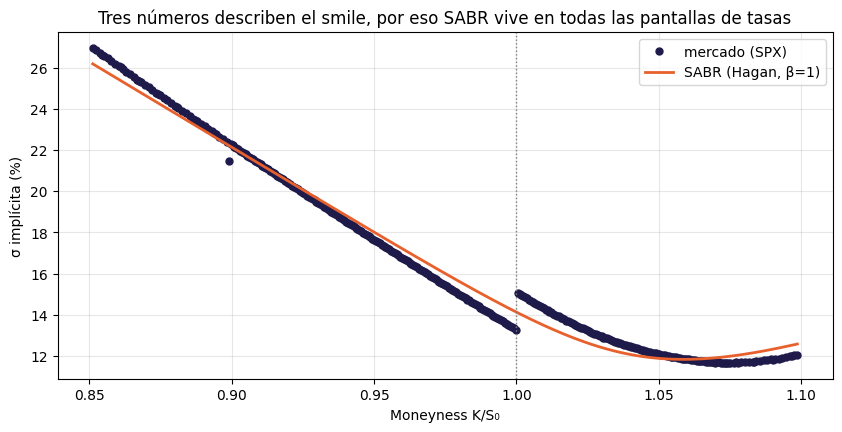

In [ ]:
# ── Ajustar (α, ρ, ν) con β = 1 fijo ─────────────────────────────────────────
F = S0x * np.exp((0.037 - 0.013)*Tx)          # el forward (CIP de la clase 1, ¡otra vez!)

def error_sabr(p):
    return np.sum((sabr_iv(Kx, F, Tx, *p) - ivx)**2)

res = minimize(error_sabr, x0=[0.14, -0.6, 1.5], method='Nelder-Mead',
               bounds=[(0.01, 1.0), (-0.999, 0.999), (0.01, 10)])
alpha, rho, nu = res.x
rmse_bp = np.sqrt(res.fun/len(Kx))*1e4

print(f'SABR calibrado (β=1):  α = {alpha:.3f} | ρ = {rho:+.2f} | ν = {nu:.2f}   (RMSE {rmse_bp:.0f} bp de vol)')
print()
print(f'Lectura de trader (qué representa cada parámetro):')
print(f'   α = {alpha:.3f}  → el nivel ATM del smile')
print(f'   ρ = {rho:+.2f}   → la asimetría/skew')
print(f'   ν = {nu:.2f}    → vol-of-vol, cuánto se curvan las alas')

K_fina = np.linspace(Kx.min(), Kx.max(), 200)
plt.plot(Kx/S0x, ivx*100, 'o', color=NAVY, ms=5, label='mercado (SPX)')
plt.plot(K_fina/S0x, sabr_iv(K_fina, F, Tx, alpha, rho, nu)*100, color=ORANGE, lw=2,
         label='SABR (Hagan, β=1)')
plt.axvline(1.0, color='gray', ls=':', lw=1)
plt.xlabel('Moneyness K/S₀'); plt.ylabel('σ implícita (%)')
plt.title('Tres números describen el smile, por eso SABR vive en todas las pantallas de tasas')
plt.legend(); plt.show()

---
# Extra (opcional, si sobra tiempo): cuando el precio salta — Merton (1976) jump-diffusion

## La idea

La teórica (§1) lo nombra: sumarle al browniano de Black-Scholes un proceso de saltos.

$$\frac{dS}{S} = (r - \lambda k)\,dt + \sigma\,dW + dJ, \qquad J = \text{Poisson compuesto}$$

Los saltos llegan con intensidad $\lambda$ (un proceso de Poisson) y tienen tamaño aleatorio $Y$,
con $\log(1+Y) \sim \mathcal{N}(\mu_J, \delta^2)$ (Merton, 1976). $k=\mathbb{E}[Y]$ compensa el
drift para que el proceso siga sin arbitraje bajo $\mathbb{Q}$.

**Por qué hace falta:** una difusión pura necesita TIEMPO para acumular colas gordas (muchos pasos
chicos); un salto puede pasar mañana. Por eso Heston (Ejercicio 2) aplana el skew cuando $T\to 0$
y el mercado no — el "crash overnight" que ninguna difusión fabrica.

La fórmula de Merton (semi-cerrada): condicional en que hubo $n$ saltos, es un Black-Scholes con
vol y tasa ajustadas, promediado sobre la probabilidad de Poisson de tener $n$ saltos:

$$C_{Merton} = \sum_{n=0}^{\infty} \frac{e^{-\lambda' T}(\lambda' T)^n}{n!}\,BS(S,K,T,r_n,\sigma_n)$$

con $\lambda'=\lambda(1+k)$, $\sigma_n=\sqrt{\sigma^2+n\delta^2/T}$, $r_n=r-\lambda k + n\ln(1+k)/T$.

No es un ejercicio evaluable — corran las dos celdas y comparen contra lo que vieron en el
Ejercicio 2.


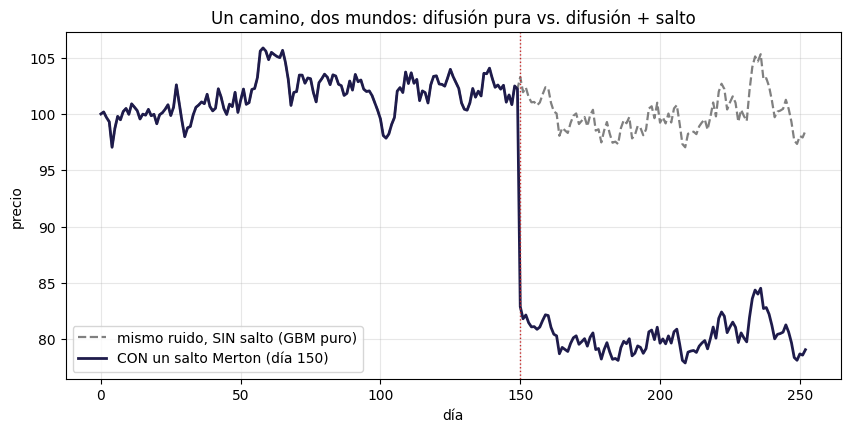

In [ ]:
# ── Un camino, dos mundos: mismo ruido, con y sin un salto ────────────────────
rng = np.random.default_rng(2)
n_steps, T_path = 252, 1.0
dt = T_path / n_steps
sigma_p, mu_p = 0.15, 0.02

z = rng.standard_normal(n_steps)
incrementos = (mu_p - 0.5*sigma_p**2)*dt + sigma_p*np.sqrt(dt)*z
log_gbm = np.concatenate([[0.0], np.cumsum(incrementos)])

dia_salto, salto = 150, -0.22          # un crash de ~20% en un solo día
log_jump = log_gbm.copy()
log_jump[dia_salto:] += salto

S0 = 100.0
dias = np.arange(n_steps + 1)
S_gbm, S_jump = S0*np.exp(log_gbm), S0*np.exp(log_jump)

plt.figure(figsize=(10, 4.5))
plt.plot(dias, S_gbm, color='gray', lw=1.6, ls='--', label='mismo ruido, SIN salto (GBM puro)')
plt.plot(dias, S_jump, color=NAVY, lw=2, label='CON un salto Merton (día 150)')
plt.axvline(dia_salto, color=RED, lw=1, ls=':')
plt.xlabel('día'); plt.ylabel('precio')
plt.title('Un camino, dos mundos: difusión pura vs. difusión + salto')
plt.legend(); plt.show()

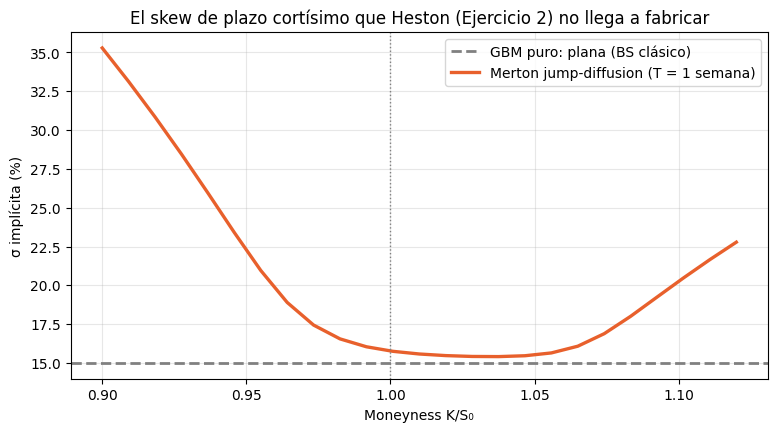

In [ ]:
# ── La fórmula de Merton (1976): suma de Poisson de precios Black-Scholes ────
from math import factorial

def merton_call(S, K, T, r, sigma, lam, mu_j, delta_j, n_terms=15):
    # Precio call de Merton: BS promediado sobre la probabilidad de Poisson
    # de que hayan ocurrido n saltos, con vol y tasa ajustadas por n.
    k = np.exp(mu_j + 0.5*delta_j**2) - 1        # E[Y]: compensa el drift del salto bajo Q
    lam_p = lam * (1 + k)
    total = 0.0
    for n in range(n_terms):
        sigma_n = np.sqrt(sigma**2 + n*delta_j**2/T)
        r_n = r - lam*k + n*np.log(1+k)/T
        peso = np.exp(-lam_p*T) * (lam_p*T)**n / factorial(n)
        total += peso * bs_call(S, K, T, r_n, sigma_n)
    return total

T_short = 7/365
r, sigma_d = 0.04, 0.15
lam, mu_j, delta_j = 0.5, -0.10, 0.08     # ~1 salto cada 2 años, tamaño medio -10%
K = np.linspace(90, 112, 25)
S0b = 100.0

iv_merton = [vol_implicita(merton_call(S0b, Kk, T_short, r, sigma_d, lam, mu_j, delta_j),
                            S0b, Kk, T_short, r) for Kk in K]

plt.figure(figsize=(9, 4.5))
plt.axhline(sigma_d*100, color='gray', lw=2, ls='--', label='GBM puro: plana (BS clásico)')
plt.plot(K/S0b, np.array(iv_merton)*100, color=ORANGE, lw=2.4, label='Merton jump-diffusion (T = 1 semana)')
plt.axvline(1.0, color='gray', lw=1, ls=':')
plt.xlabel('Moneyness K/S₀'); plt.ylabel('σ implícita (%)')
plt.title('El skew de plazo cortísimo que Heston (Ejercicio 2) no llega a fabricar')
plt.legend(); plt.show()